In [1]:
import sys
import os
from glob import glob

import numpy as np
import pandas as pd
from tabulate import tabulate
from scipy.integrate import cumtrapz
from parmed.amber import NetCDFTraj, AmberParm
from qmhub.units import AMBER_HARTREE_TO_KCAL, AMBER_BOHR_TO_A

In [2]:
!pwd

/scratch/van/cas9/hnh/b3lyp-pm3-sinr2/ene_decomp


In [3]:
def vector_cosine(vector1, vector2):
    vector1 = np.asarray(vector1)
    vector2 = np.asarray(vector2)
    scalar_input = False
    if vector1.ndim == 1:
        vector1 = vector1[None]  # Makes vector1 2D
        vector2 = vector2[None]  # Makes vector2 2D
        scalar_input = True

    ret = np.zeros(len(vector1))
    for i, (v1, v2) in enumerate(zip(vector1, vector2)):
        ret[i] = np.dot(v1, v2) / np.linalg.norm(v1) / np.linalg.norm(v2)

    if scalar_input:
        return np.squeeze(ret)
    return ret 

def mean_force_otter(pos, force):
    f1 = np.dot(force[0] - force[1], pos[0] - pos[1]) / np.linalg.norm(pos[0] - pos[1])
    f2 = np.dot(force[2] - force[1], pos[2] - pos[1]) / np.linalg.norm(pos[2] - pos[1])
    cosa = vector_cosine(pos[0] - pos[1], pos[2] - pos[1])
    return (f1 - f2) / (4 - 2 * cosa)

# r1 should be the longer distance at the reactant side

def mean_force_otter_geom(pos):
    r1 = np.linalg.norm(pos[0] - pos[1])
    r2 = np.linalg.norm(pos[2] - pos[1])
    cosa = vector_cosine(pos[0] - pos[1], pos[2] - pos[1])
    return (4 + (1 - cosa**2) / (2 - cosa)) * (1 / r1 - 1 / r2) / (4 - 2 * cosa) / 1.677399001146518


def get_pmf(forces, positions):
    mean_forces = []
    for force, pos in zip(forces, positions):
        mean_force = np.zeros(len(pos))
        for j in range(len(pos)):
            mean_force[j] = mean_force_otter(pos[j], force[j])
        mean_forces.append(mean_force)
    mean_forces = np.array(mean_forces)
    mean = np.array(mean_forces).mean(axis=1)
    mean_var = mean_forces.var(axis=1) / mean_forces.shape[1]
    return cumtrapz(mean, dx=0.1), np.sqrt(cumtrapz(mean_var, dx=0.1))


def get_pmf_geom(positions):
    mean_forces = []
    for pos in positions:
        mean_force = np.zeros(len(pos))
        for j in range(len(pos)):
            mean_force[j] = mean_force_otter_geom(pos[j])
        mean_forces.append(mean_force)
    mean_forces = np.array(mean_forces)
    mean = np.array(mean_forces).mean(axis=1)
    mean_var = mean_forces.var(axis=1) / mean_forces.shape[1]
    return cumtrapz(mean, dx=0.1), np.sqrt(cumtrapz(mean_var, dx=0.1))


In [4]:
n_windows = 42
nbins = n_windows - 1

prot_name = "WT"
num_prot_atoms = 27086

qm_index2 = np.array([60, 53, 52], dtype=int) - 1 # MM Number to Python
qm_index = np.array([27261,26639,26638], dtype=int) - 1 # MM Number to Python

parm = AmberParm("../input/step3_pbcsetup.parm7")

In [5]:
# # UNCOMMENT TO CHANGE TRAJ

# # 3.4 sec / window
# pos_all = []
# for i in range(n_windows):
#     pos = []
#     traj = NetCDFTraj.open_old("../%02d/step7_reprocessing.nc" % i)
#     # for j in range(5):
#     #     traj = NetCDFTraj.open_old("../%02d/step6.%02d_equilibration.nc" % (i, j) )
#     pos.append(traj.coordinates[:, qm_index])
#     traj.close()
#     pos_all.append(np.concatenate(pos))
# np.save('pos_all', pos_all)

In [5]:
# coords = np.load('pos_all.npy')
# pos_all = coords[:n_windows,:500:2,:,:] # [ windows , frames , coordinate, qm_atoms ]

# np.save('pos_all.npy', pos_all)

In [6]:
# got MM atom numbers from step5.00_equilibration.mdout
# grep "QMMM:     1" step5.00_equilibration.mdout -A 67 |awk '{print $3}' | tr '\n' ','

arr = np.array([13767,13768,13769,13770,13771,13772,13779,13780,13781,13782,13783,13784,13785,13786,13787,13788,
         13789,14154,14155,14156,14157,14158,14159,14160,14161,22499,26613,26614,26615,26616,26617,26618,
         26619,26620,26621,26622,26623,26624,26625,26626,26627,26628,26629,26630,26631,26632,26633,26634,
         26635,26636,26637,26638,26639,26640,26641,26642,26643,26644,26645], dtype=int) - 1

#water atoms
#27261,27262,27263,27267,27268,27269,27270,27271,27272]

# total number of non-water atoms minus 1
num_prot_atoms2 = 27146 - 1
resid = np.zeros(num_prot_atoms2, dtype=int)
for i in range(num_prot_atoms2):
    resid[i] = parm.atoms[i].residue.idx


resid = np.delete(resid,arr)
num_prot_res = resid[-1]

res_names = []
for i in np.unique(resid):
    if i <= 1364:
        _res_id = i + 2
        res_names.append("Prot-" + parm.residues[i].name.capitalize() + "%d" % _res_id )
    elif 1365 <= i <= 1368:
        _res_id = i + 2
        res_names.append("MGs-" + parm.residues[i].name.capitalize() + "%d" % _res_id )
    elif 1369 <= i <= 1466:
        _res_id = i + 2
        res_names.append("RNA-" + parm.residues[i].name.capitalize() + "%d" % _res_id )
    elif 1467 <= i <= 1515:
        _res_id = i + 2
        res_names.append("DNA-" + parm.residues[i].name.capitalize() + "%d" % _res_id )

In [8]:
res_names.append('Near')
res_names.append('Far')

np.save('res_names', res_names)

In [9]:
qmmm_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/qmmm_forces.npy" % i).swapaxes(1, 2) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    qmmm_forces.append(force[:, qm_index2])
qmmm_forces = np.array(qmmm_forces)

qmmm_prot_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/qmmm_prot_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    qmmm_prot_forces.append(force.sum(axis=3))
qmmm_prot_forces = np.array(qmmm_prot_forces)

qmmm_res_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/qmmm_prot_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    force2 = np.zeros((250, 3, 3, num_prot_res))
    for i in range(num_prot_res):
        force2[:, :, :, i] = force[:, :, :, resid == i].sum(axis=3)
    qmmm_res_forces.append(force2)
qmmm_res_forces = np.array(qmmm_res_forces)

qmmm_near_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/qmmm_near_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    qmmm_near_forces.append(force)
qmmm_near_forces = np.array(qmmm_near_forces)

qmmm_far_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/qmmm_far_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    qmmm_far_forces.append(force)
qmmm_far_forces = np.array(qmmm_far_forces)

In [13]:
qmmm_res_forces[0].shape

(250, 3, 3, 1512)

In [10]:
print(qmmm_res_forces.shape, qmmm_near_forces.shape, qmmm_far_forces.shape)

(42, 250, 3, 3, 1512) (42, 250, 3, 3) (42, 250, 3, 3)


In [22]:
gas_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/gas_forces.npy" % i).swapaxes(1, 2) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    gas_forces.append(force[:, qm_index2])
gas_forces = np.array(gas_forces)

prot_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/gas_prot_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    prot_forces.append(force.sum(axis=3))
prot_forces = np.array(prot_forces)

res_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/gas_prot_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    force2 = np.zeros((len(force), 3, 3, num_prot_res))
    for i in range(num_prot_res):
        force2[:, :, :, i] = force[:, :, :, resid == i].sum(axis=3)
    res_forces.append(force2)
res_forces = np.array(res_forces)

near_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/gas_near_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    near_forces.append(force)
near_forces = np.array(near_forces)

far_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/ene_decomp/gas_far_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    far_forces.append(force)
far_forces = np.array(far_forces)

In [25]:
vdw_prot_forces = []
for i in range(n_windows):
    # force = np.load("../%02d/ljt_forces.npy" % i)
    # vdw_prot_forces.append(force.sum(axis=3))
    force = np.load("../%02d/ene_decomp/lj_prot_forces_sum.npy" % i)
    vdw_prot_forces.append(force)
vdw_prot_forces = np.array(vdw_prot_forces)

vdw_res_forces = []
for i in range(n_windows):
    force = np.load("../%02d/ene_decomp/lj_prot_forces.npy" % i)
    force2 = np.zeros((len(force), 3, 3, num_prot_res))
    for i in range(num_prot_res):
        force2[:, :, :, i] = force[:, :, :, resid == i].sum(axis=3)
    vdw_res_forces.append(force2)
vdw_res_forces = np.array(vdw_res_forces)

vdw_near_forces = []
for i in range(n_windows):
    force = np.load("../%02d/ene_decomp/lj_near_forces.npy" % i)
    vdw_near_forces.append(force)
vdw_near_forces = np.array(vdw_near_forces)

In [26]:
# # Using VDW prot + near forces from Reprocessing w/ printing forces to check my LJ script

# from parmed.amber import NetCDFTraj

# vdw_forces = []
# for i in range(n_windows):
#     traj = NetCDFTraj.open_old("../%02d/step7_reprocessing2.nc" % i)    
#     vdw_forces.append(traj.forces[::2, qm_index])
#     traj.close()
# vdw_forces = np.array(vdw_forces)
# np.save('vdw_forces_reprocess', vdw_forces)

In [27]:
# Do not need to swap axis since shape is already (250, 73, 3)

pcm_forces = []
for i in range(n_windows):
    force = -1 * np.load("../%02d/qmmm_grad_pcm.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
    pcm_forces.append(force[:, qm_index2])
pcm_forces = np.array(pcm_forces)

In [29]:
pmf_geom, pmf_geom_std = get_pmf_geom(pos_all)
pmf_vdw, pmf_vdw_std = get_pmf(vdw_prot_forces + vdw_near_forces, pos_all)
# pmf_vdwf, pmf_vdwf_std = get_pmf(vdw_forces, pos_all)
pmf_total, pmf_total_std = get_pmf(vdw_prot_forces + vdw_near_forces + qmmm_forces, pos_all)

In [30]:
pmf_qmmm, pmf_qmmm_std = get_pmf(qmmm_forces, pos_all)
pmf_prot_qmmm, pmf_prot_qmmm_std = get_pmf(vdw_prot_forces + qmmm_forces, pos_all)
pmf_near_qmmm, pmf_near_qmmm_std = get_pmf(vdw_near_forces + qmmm_forces, pos_all)

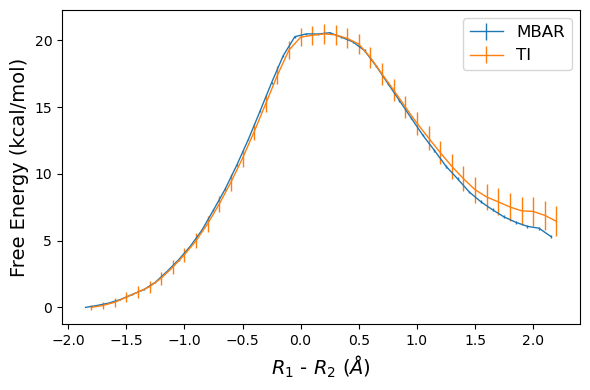

In [31]:
# Checking if TI matches MBAR

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
free_mbar = np.loadtxt('../mbar/freefile_mbar_allstep6')

val_min = -1.9
val_max =  2.2

bin_edges = np.linspace(val_min, val_max, nbins+1)
bin_centers = np.zeros(nbins)
for i in range(nbins):
    bin_centers[i] = (bin_edges[i] + bin_edges[i+1]) / 2.0

ax.errorbar(free_mbar[:,0], free_mbar[:,1] - free_mbar[:10,1].min(), yerr=free_mbar[:,2], linewidth=1, label="MBAR")
# plt.errorbar(bin_centers + 0.05, pmf_qmmm - pmf_qmmm[:10].min(), yerr=pmf_qmmm_std, linewidth=1, label="QMMM")
# plt.errorbar(bin_centers + 0.05, pmf_vdw - pmf_vdw[:10].max(), yerr=pmf_vdw_std, linewidth=1, label="VDW (prot + near)")
# plt.errorbar(bin_centers + 0.05, pmf_vdwf - pmf_vdwf[:10].min(), yerr=pmf_vdwf_std, linewidth=1, label="VDW (reprocess)")
# plt.errorbar(bin_centers + 0.05, pmf_prot_qmmm - pmf_prot_qmmm[:10].min(), yerr=pmf_prot_qmmm_std, linewidth=1, label="vdw_prot + QMMM")
# plt.errorbar(bin_centers + 0.05, pmf_near_qmmm - pmf_near_qmmm[:10].min(), yerr=pmf_near_qmmm_std, linewidth=1, label="vdw_near + QMMM")
ax.errorbar(bin_centers + 0.05, pmf_total - pmf_total[:10].min(), yerr=pmf_total_std, linewidth=1, label="TI")
plt.legend(fontsize=12)
plt.xlabel('$R_{1}$ - $R_{2}$ ($\AA$)',fontsize=14)
plt.ylabel('Free Energy (kcal/mol)',fontsize=14)
plt.tight_layout()
# plt.savefig('pmf-TI.png', dpi=300)

# np.save('freefile_ti', np.column_stack((bin_centers, pmf_total, pmf_total_std)))

In [32]:
pmf_qmmm, pmf_qmmm_std = get_pmf(qmmm_forces, pos_all)
pmf_gas, pmf_gas_std = get_pmf(gas_forces, pos_all)
pmf_pcm, pmf_pcm_std = get_pmf(pcm_forces, pos_all)
pmf_elec, pmf_elec_std = get_pmf(qmmm_forces - gas_forces, pos_all)
pmf_perm, pmf_perm_std = get_pmf(prot_forces + near_forces + far_forces, pos_all)
pmf_pol, pmf_pol_std = get_pmf(qmmm_forces - gas_forces - prot_forces - near_forces - far_forces, pos_all)

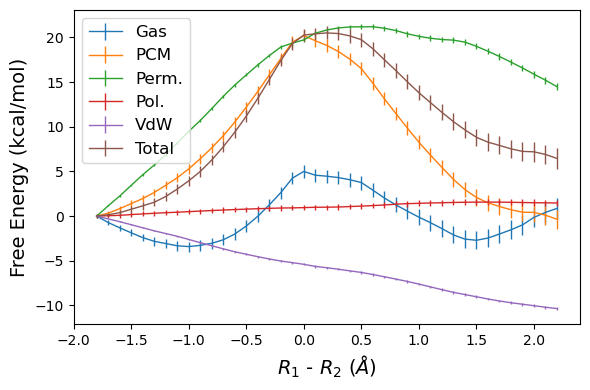

In [34]:
fig, ax = plt.subplots(figsize=(6,4))

ax.errorbar(bin_centers + 0.05, pmf_gas  - pmf_gas[0] , yerr=pmf_gas_std , linewidth=1, label="Gas")
ax.errorbar(bin_centers + 0.05, pmf_pcm  - pmf_pcm[0] , yerr=pmf_pcm_std , linewidth=1, label="PCM")
ax.errorbar(bin_centers + 0.05, pmf_perm - pmf_perm[0], yerr=pmf_perm_std, linewidth=1, label="Perm.")
ax.errorbar(bin_centers + 0.05, pmf_pol  - pmf_pol[0] , yerr=pmf_pol_std , linewidth=1, label="Pol.")
ax.errorbar(bin_centers + 0.05, pmf_vdw  - pmf_vdw[0] , yerr=pmf_vdw_std , linewidth=1, label="VdW")
ax.errorbar(bin_centers + 0.05, pmf_total  - pmf_total[0] , yerr=pmf_total_std , linewidth=1, label="Total")
plt.legend(fontsize=12)
plt.xlabel('$R_{1}$ - $R_{2}$ ($\AA$)',fontsize=14)
plt.ylabel('Free Energy (kcal/mol)',fontsize=14)
plt.tight_layout()
# plt.savefig('pmf_decomp.png', dpi=300)

np.save('freefile/freefile_pmf_pcm',   np.column_stack((bin_centers, pmf_pcm,  pmf_pcm_std)))

# np.save('freefile_pmf_gas',   np.column_stack((bin_centers, pmf_gas,  pmf_gas_std)))
# np.save('freefile_pmf_perm',  np.column_stack((bin_centers, pmf_perm, pmf_perm_std)))
# np.save('freefile_pmf_pol',   np.column_stack((bin_centers, pmf_pol,  pmf_pol_std)))
# np.save('freefile_pmf_vdw',   np.column_stack((bin_centers, pmf_vdw,  pmf_vdw_std)))
# np.save('freefile_pmf_total', np.column_stack((bin_centers, pmf_total,pmf_total_std)))

In [17]:
print('Gas  ', max(pmf_gas   -  pmf_gas[0]))
print('Perm.', max(pmf_perm  -  pmf_perm[0]))
print('Pol. ', max(pmf_pol   -  pmf_pol[0])) 
print('VdW  ', max(pmf_vdw   -  pmf_vdw[0])) 
print('Total', max(pmf_total -  pmf_total[0])) 

Gas   4.994397897304243
Perm. 21.18362911352954
Pol.  1.5642571731834138
VdW   0.0
Total 20.491884670685838


In [21]:
print(pmf_vdw)

[ -0.30578679  -0.62495721  -0.93263931  -1.27155443  -1.61650604
  -1.9562195   -2.26317601  -2.56757547  -2.92203075  -3.28479742
  -3.62787416  -3.97065048  -4.30033802  -4.58037861  -4.85030491
  -5.1078593   -5.33720885  -5.51573917  -5.7037783   -5.93875381
  -6.08606422  -6.25372365  -6.43686387  -6.61222357  -6.84450521
  -7.09452629  -7.35812862  -7.61960833  -7.91667713  -8.22864248
  -8.54000747  -8.83791387  -9.08839327  -9.33428103  -9.58262575
  -9.80716256 -10.00495963 -10.17010356 -10.33492211 -10.50761194
 -10.65887954]


In [18]:
pmf_delta_qmmm, pmf_delta_qmmm_std = get_pmf(qmmm_prot_forces + qmmm_near_forces + qmmm_far_forces - prot_forces - near_forces - far_forces, pos_all)
pmf_dist, pmf_dist_std = get_pmf(qmmm_forces - gas_forces - qmmm_prot_forces - qmmm_near_forces - qmmm_far_forces, pos_all)

In [18]:
pmf_elec_res = np.zeros((num_prot_res, nbins))
pmf_elec_res_std = np.zeros((num_prot_res, nbins))
elec_res_forces = 0.5 * (qmmm_res_forces + res_forces)
for i in range(num_prot_res):
    pmf_elec_res[i], pmf_elec_res_std[i] = get_pmf(elec_res_forces[:, :, :, :, i], pos_all)
pmf_near_elec, pmf_near_elec_std = get_pmf(0.5 * (qmmm_near_forces + near_forces), pos_all)
pmf_far_elec, pmf_far_elec_std = get_pmf(0.5 * (qmmm_far_forces + far_forces), pos_all)

pmf_perm_res = np.zeros((num_prot_res, nbins))
pmf_perm_res_std = np.zeros((num_prot_res, nbins))
for i in range(num_prot_res):
    pmf_perm_res[i], pmf_perm_res_std[i] = get_pmf(res_forces[:, :, :, :, i], pos_all)
pmf_near_perm, pmf_near_perm_std = get_pmf(near_forces, pos_all)
pmf_far_perm, pmf_far_perm_std = get_pmf(far_forces, pos_all)

pmf_pol_res = np.zeros((num_prot_res, nbins))
pmf_pol_res_std = np.zeros((num_prot_res, nbins))
pol_res_forces = 0.5 * (qmmm_res_forces - res_forces)
for i in range(num_prot_res):
    pmf_pol_res[i], pmf_pol_res_std[i] = get_pmf(pol_res_forces[:, :, :, :, i], pos_all)
pmf_near_pol, pmf_near_pol_std = get_pmf(0.5 * (qmmm_near_forces - near_forces), pos_all)
pmf_far_pol, pmf_far_pol_std = get_pmf(0.5 * (qmmm_far_forces - far_forces), pos_all)

pmf_vdw_res = np.zeros((num_prot_res, nbins))
pmf_vdw_res_std = np.zeros((num_prot_res, nbins))
for i in range(num_prot_res):
    pmf_vdw_res[i], pmf_vdw_res_std[i] = get_pmf(vdw_res_forces[:, :, :, :, i], pos_all)
pmf_near_vdw, pmf_near_vdw_std = get_pmf(vdw_near_forces, pos_all)

pmf_total_res = np.zeros((num_prot_res, nbins))
pmf_total_res_std = np.zeros((num_prot_res, nbins))
total_res_forces = 0.5 * (qmmm_res_forces + res_forces) + vdw_res_forces
for i in range(num_prot_res):
    pmf_total_res[i], pmf_total_res_std[i] = get_pmf(total_res_forces[:, :, :, :, i], pos_all)
pmf_near_total, pmf_near_total_std = get_pmf(0.5 * (qmmm_near_forces + near_forces) + vdw_near_forces, pos_all)

In [19]:
maxbin=(pmf_total).argmax()
minbin=(pmf_total).argmin()
print(maxbin, minbin)

20 0


In [20]:
# Total-FEP-Decomposition

barrier_perm_res = np.zeros((num_prot_res, 2))
barrier_pol_res = np.zeros((num_prot_res, 2))
barrier_elec_res = np.zeros((num_prot_res, 2))
barrier_vdw_res = np.zeros((num_prot_res, 2))
barrier_total_res = np.zeros((num_prot_res, 2))

# Remove negative when correcting r1
maxbin=(pmf_total).argmax()
minbin=(pmf_total).argmin()

for i in range(num_prot_res):
    barrier_perm_res[i] = [pmf_perm_res[i, maxbin] - pmf_perm_res[i, minbin], pmf_perm_res_std[i, maxbin]]
    barrier_pol_res[i] = [pmf_pol_res[i, maxbin] - pmf_pol_res[i, minbin], pmf_pol_res_std[i, maxbin]]
    barrier_elec_res[i] = [pmf_elec_res[i, maxbin] - pmf_elec_res[i, minbin], pmf_elec_res_std[i, maxbin]]
    barrier_vdw_res[i] = [pmf_vdw_res[i, maxbin] - pmf_vdw_res[i, minbin], pmf_vdw_res_std[i, maxbin]]
    barrier_total_res[i] = [pmf_total_res[i, maxbin] - pmf_total_res[i, minbin], pmf_total_res_std[i, maxbin]]

barrier_near_perm = pmf_near_perm[maxbin] - pmf_near_perm[minbin]
barrier_near_perm_std = pmf_near_perm_std[maxbin]

barrier_far_perm = pmf_far_perm[maxbin] - [minbin]
barrier_far_perm_std = pmf_far_perm_std[maxbin]

barrier_near_pol = pmf_near_pol[maxbin] - pmf_near_pol[minbin]
barrier_near_pol_std = pmf_near_pol_std[maxbin]

barrier_far_pol = pmf_far_pol[maxbin] - pmf_far_pol[minbin]
barrier_far_pol_std = pmf_far_pol_std[maxbin]

barrier_near_elec = pmf_near_elec[maxbin] - pmf_near_elec[minbin]
barrier_near_elec_std = pmf_near_elec_std[maxbin]

barrier_far_elec = pmf_far_elec[maxbin] - pmf_far_elec[minbin]
barrier_far_elec_std = pmf_far_elec_std[maxbin]

barrier_near_vdw = pmf_near_vdw[maxbin] - pmf_near_vdw[minbin]
barrier_near_vdw_std = pmf_near_vdw_std[maxbin]

barrier_far_vdw = 0.0
barrier_far_vdw_std = 0.0

barrier_near_total = pmf_near_total[maxbin] - pmf_near_total[minbin]
barrier_near_total_std = pmf_near_total_std[maxbin]

barrier_total, barrier_total_std = pmf_total[maxbin] - pmf_total[minbin], pmf_total_std[maxbin]
barrier_vdw, barrier_vdw_std = pmf_vdw[maxbin] - pmf_vdw[minbin], pmf_vdw_std[maxbin]
barrier_gas, barrier_gas_std = pmf_gas[maxbin] - pmf_gas[minbin], pmf_gas_std[maxbin]
barrier_perm, barrier_perm_std = pmf_perm[maxbin] - pmf_perm[minbin], pmf_perm_std[maxbin]
barrier_pol, barrier_pol_std = pmf_pol[maxbin] - pmf_pol[minbin], pmf_pol_std[maxbin]
barrier_geom, barrier_geom_std = pmf_geom[maxbin] - pmf_geom[minbin], pmf_geom_std[maxbin]

In [20]:
# Visualization for Decomp.

# mm_atom_forces = []
# for i in range(n_windows):
#     force1 = -1 * np.load("../%02d/gas_prot_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
#     force2 = -1 * np.load("../%02d/qmmm_prot_forces.npy" % i) * (AMBER_HARTREE_TO_KCAL / AMBER_BOHR_TO_A)
#     mm_atom_forces.append(0.5 * (force1 + force2))
# mm_atom_forces = np.array(mm_atom_forces)

# mm_barrier_pot = np.zeros((num_prot_atoms, 2))

# for i in range(num_prot_atoms):
#     pmf_mm_atom, pmf_mm_atom_std = get_pmf(mm_atom_forces[:, :, :, :, i], pos_all)
#     barrier_mm_atom, barrier_mm_atom_std = pmf_mm_atom[maxbin] - pmf_mm_atom[minbin], pmf_mm_atom_std[maxbin]
#     mm_barrier_pot[i] = barrier_mm_atom / parm.atoms[i].charge, barrier_mm_atom_std / parm.atoms[i].charge

# np.save("mm_barrier_pot", mm_barrier_pot)
# np.savetxt("mm_barrier_pot.dat", mm_barrier_pot, fmt="%5.2f")

#==========

In [21]:
table = [
    ["Gas", barrier_gas, barrier_gas_std],
    ["Perm.", barrier_perm, barrier_perm_std],
    ["Pol.", barrier_pol, barrier_pol_std],
    ["VdW", barrier_vdw, barrier_vdw_std],
    ["Geom.", barrier_geom, barrier_geom_std],
    ["Total", barrier_total + barrier_geom, barrier_total_std + barrier_geom_std]]

print(tabulate(table, tablefmt="latex_booktabs", floatfmt=".2f"))

\begin{tabular}{lrr}
\toprule
 Gas   &  4.46 & 0.73 \\
 Perm. & 20.82 & 0.24 \\
 Pol.  &  0.99 & 0.29 \\
 VdW   & -5.78 & 0.12 \\
 Geom. & -0.14 & 0.00 \\
 Total & 20.36 & 0.72 \\
\bottomrule
\end{tabular}


In [22]:
# Per-Residue-Decomposition

multicol = pd.MultiIndex.from_tuples(
    [
        (prot_name, 'Perm.'), (prot_name, 'Perm. Std.'),
        (prot_name, 'Pol.'), (prot_name, 'Pol. Std.'),
        (prot_name, 'VdW'), (prot_name, 'VdW Std.'),
        (prot_name, 'Total'), (prot_name, 'Total Std.'),
     ])

df = pd.DataFrame(data=np.array(
    [
        barrier_perm_res[:, 0], barrier_perm_res[:, 1],
        barrier_pol_res[:, 0], barrier_pol_res[:, 1],
        barrier_vdw_res[:, 0], barrier_vdw_res[:, 1],
        barrier_total_res[:, 0], barrier_total_res[:, 1],
    ]).T,
    columns=multicol)

df2 = pd.DataFrame(data=np.array([
    [
        barrier_near_perm, barrier_near_perm_std,
        barrier_near_pol, barrier_near_pol_std,
        barrier_near_vdw, barrier_near_vdw_std,
        barrier_near_total, barrier_near_total_std,
    ],
    [
        barrier_far_perm, barrier_far_perm_std,
        barrier_far_pol, barrier_far_pol_std,
        barrier_far_vdw, barrier_far_vdw_std,
        barrier_far_elec, barrier_far_elec_std,
    ]]), columns=multicol)

df = df.append(df2)
df.index = res_names + ["Near Solv.", "Far Solv."]
df.to_pickle("barrier_res_table-new.pkl")

df3 = df[abs(df[(prot_name, 'Total')]) > 0.3].sort_values(by=(prot_name, 'Total'))

#print('Perm', 'Pol', 'vdW', 'Total')
print(tabulate(df3, tablefmt="latex_booktabs", floatfmt=".2f"))

/tmp/ipykernel_80382/1316944601.py:20: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  df2 = pd.DataFrame(data=np.array([
/tmp/ipykernel_80382/1316944601.py:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(df2)


\begin{tabular}{lrrrrrrrr}
\toprule
 Far Solv.    & -18.25 & 0.33 &  1.01 & 0.21 &  0.00 & 0.00 & -16.43 & 0.22 \\
 DNA-Dc1500   & -14.80 & 0.07 &  0.05 & 0.04 &  0.38 & 0.01 & -14.37 & 0.06 \\
 Prot-Asp850  & -10.32 & 0.03 &  1.31 & 0.02 & -0.00 & 0.00 &  -9.02 & 0.02 \\
 Prot-Asp839  &  -9.40 & 0.04 &  1.07 & 0.02 & -0.04 & 0.00 &  -8.37 & 0.03 \\
 Prot-Glu809  &  -7.26 & 0.03 & -0.22 & 0.03 &  0.00 & 0.00 &  -7.47 & 0.03 \\
 Prot-Arg864  &  -6.53 & 0.04 &  0.29 & 0.02 &  0.00 & 0.00 &  -6.23 & 0.03 \\
 Prot-Val838  &  -7.18 & 0.06 &  1.97 & 0.03 & -0.95 & 0.04 &  -6.16 & 0.07 \\
 Prot-Asp849  &  -6.59 & 0.03 &  0.94 & 0.01 &  0.00 & 0.00 &  -5.65 & 0.02 \\
 Prot-Lys866  &  -6.29 & 0.05 &  0.96 & 0.03 &  0.00 & 0.00 &  -5.33 & 0.04 \\
 RNA-A1381    &  -4.30 & 0.01 &  0.46 & 0.01 &  0.00 & 0.00 &  -3.84 & 0.01 \\
 RNA-G1380    &  -3.61 & 0.01 &  0.42 & 0.00 &  0.00 & 0.00 &  -3.19 & 0.01 \\
 RNA-A1379    &  -3.46 & 0.01 &  0.32 & 0.00 &  0.00 & 0.00 &  -3.14 & 0.01 \\
 Prot-Glu60   & 

/home/van/.Programs/miniforge3/lib/python3.9/site-packages/tabulate/__init__.py:107: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  (len(row) >= 1 and row[0] == SEPARATING_LINE)
/home/van/.Programs/miniforge3/lib/python3.9/site-packages/tabulate/__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)


In [23]:
import pickle

with open('barrier_res_table-new.pkl', 'rb') as f:
    data = pickle.load(f)
    
data.keys()

MultiIndex([('WT',      'Perm.'),
            ('WT', 'Perm. Std.'),
            ('WT',       'Pol.'),
            ('WT',  'Pol. Std.'),
            ('WT',        'VdW'),
            ('WT',   'VdW Std.'),
            ('WT',      'Total'),
            ('WT', 'Total Std.')],
           )

\begin{tabular}{lrr}
\toprule
 Gas   &  4.46 & 0.73 \\
 Perm. & 20.82 & 0.24 \\
 Pol.  &  0.99 & 0.29 \\
 VdW   & -5.78 & 0.12 \\
 Geom. & -0.14 & 0.00 \\
 Total & 20.36 & 0.72 \\
\bottomrule
\end{tabular}